student_mental_health_burnout.csv loaded
student_mental_health_burnout_1M.csv loaded
data.csv loaded
MentalHealthSurvey.csv loaded
StressLevelDataset.csv loaded

=== ALL COLUMNS ===
['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality', 'burnout_level', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'risk_level', 'dropout_risk', 'phq9', 'gad7', 'sleephours', 'exercisefreq', 'socialactivity', 'onlinestress', 'gpa', 'familysupport', 'screentime', 'academicstress', 'dietquality', 'selfefficacy', 'peerrelations

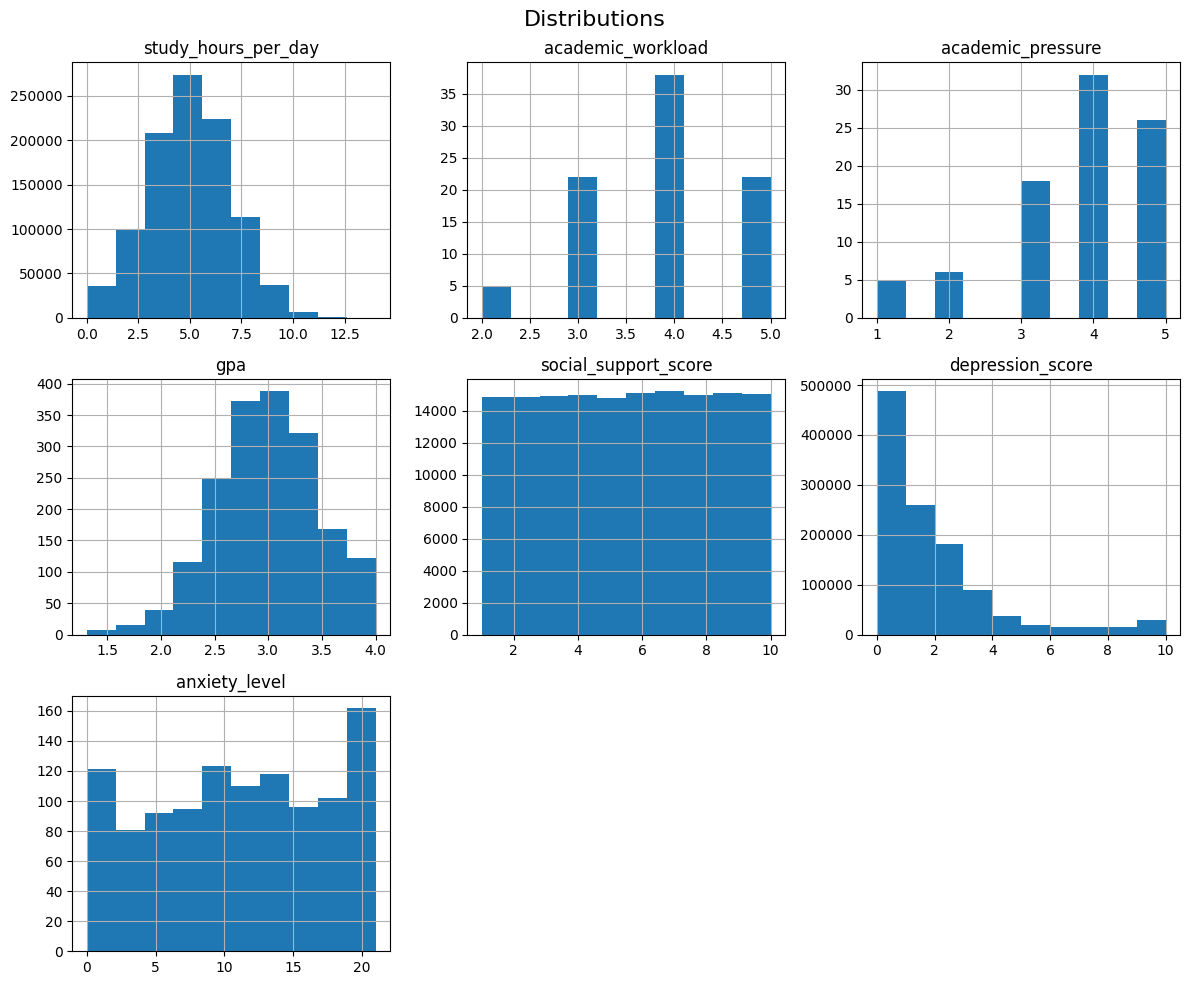

helo1


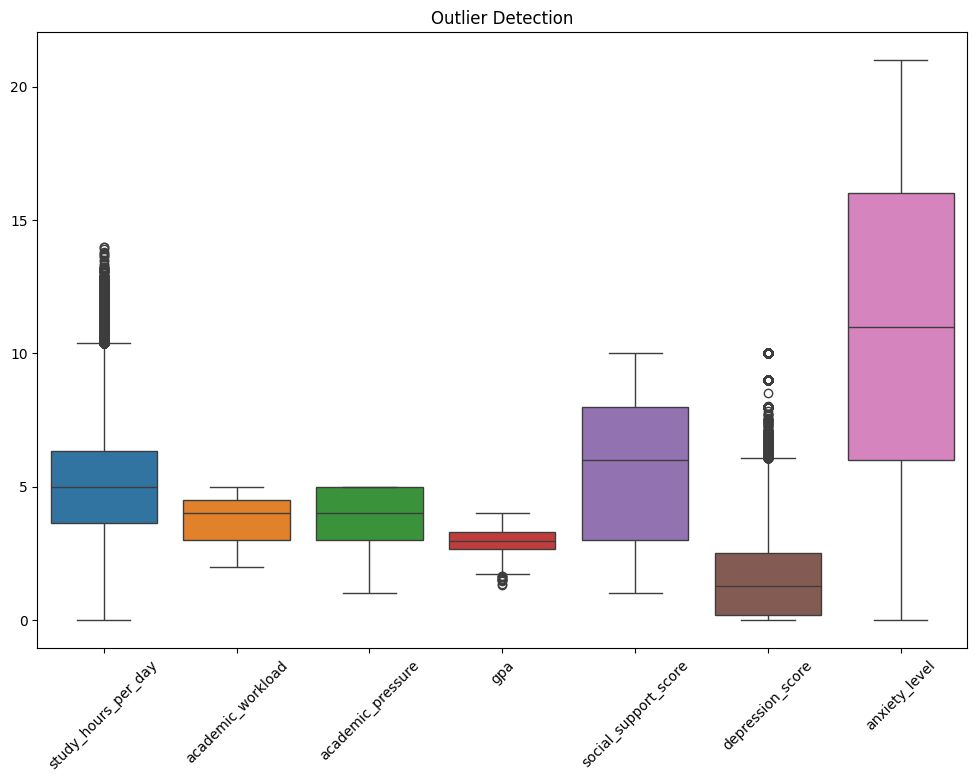

hello2


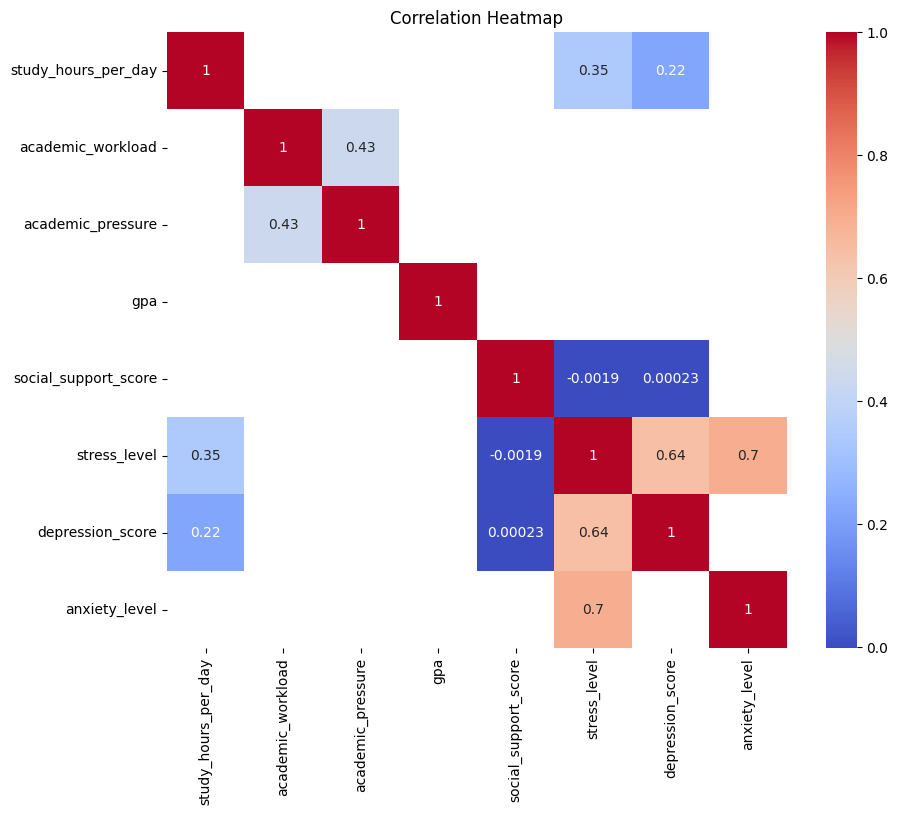

hello3


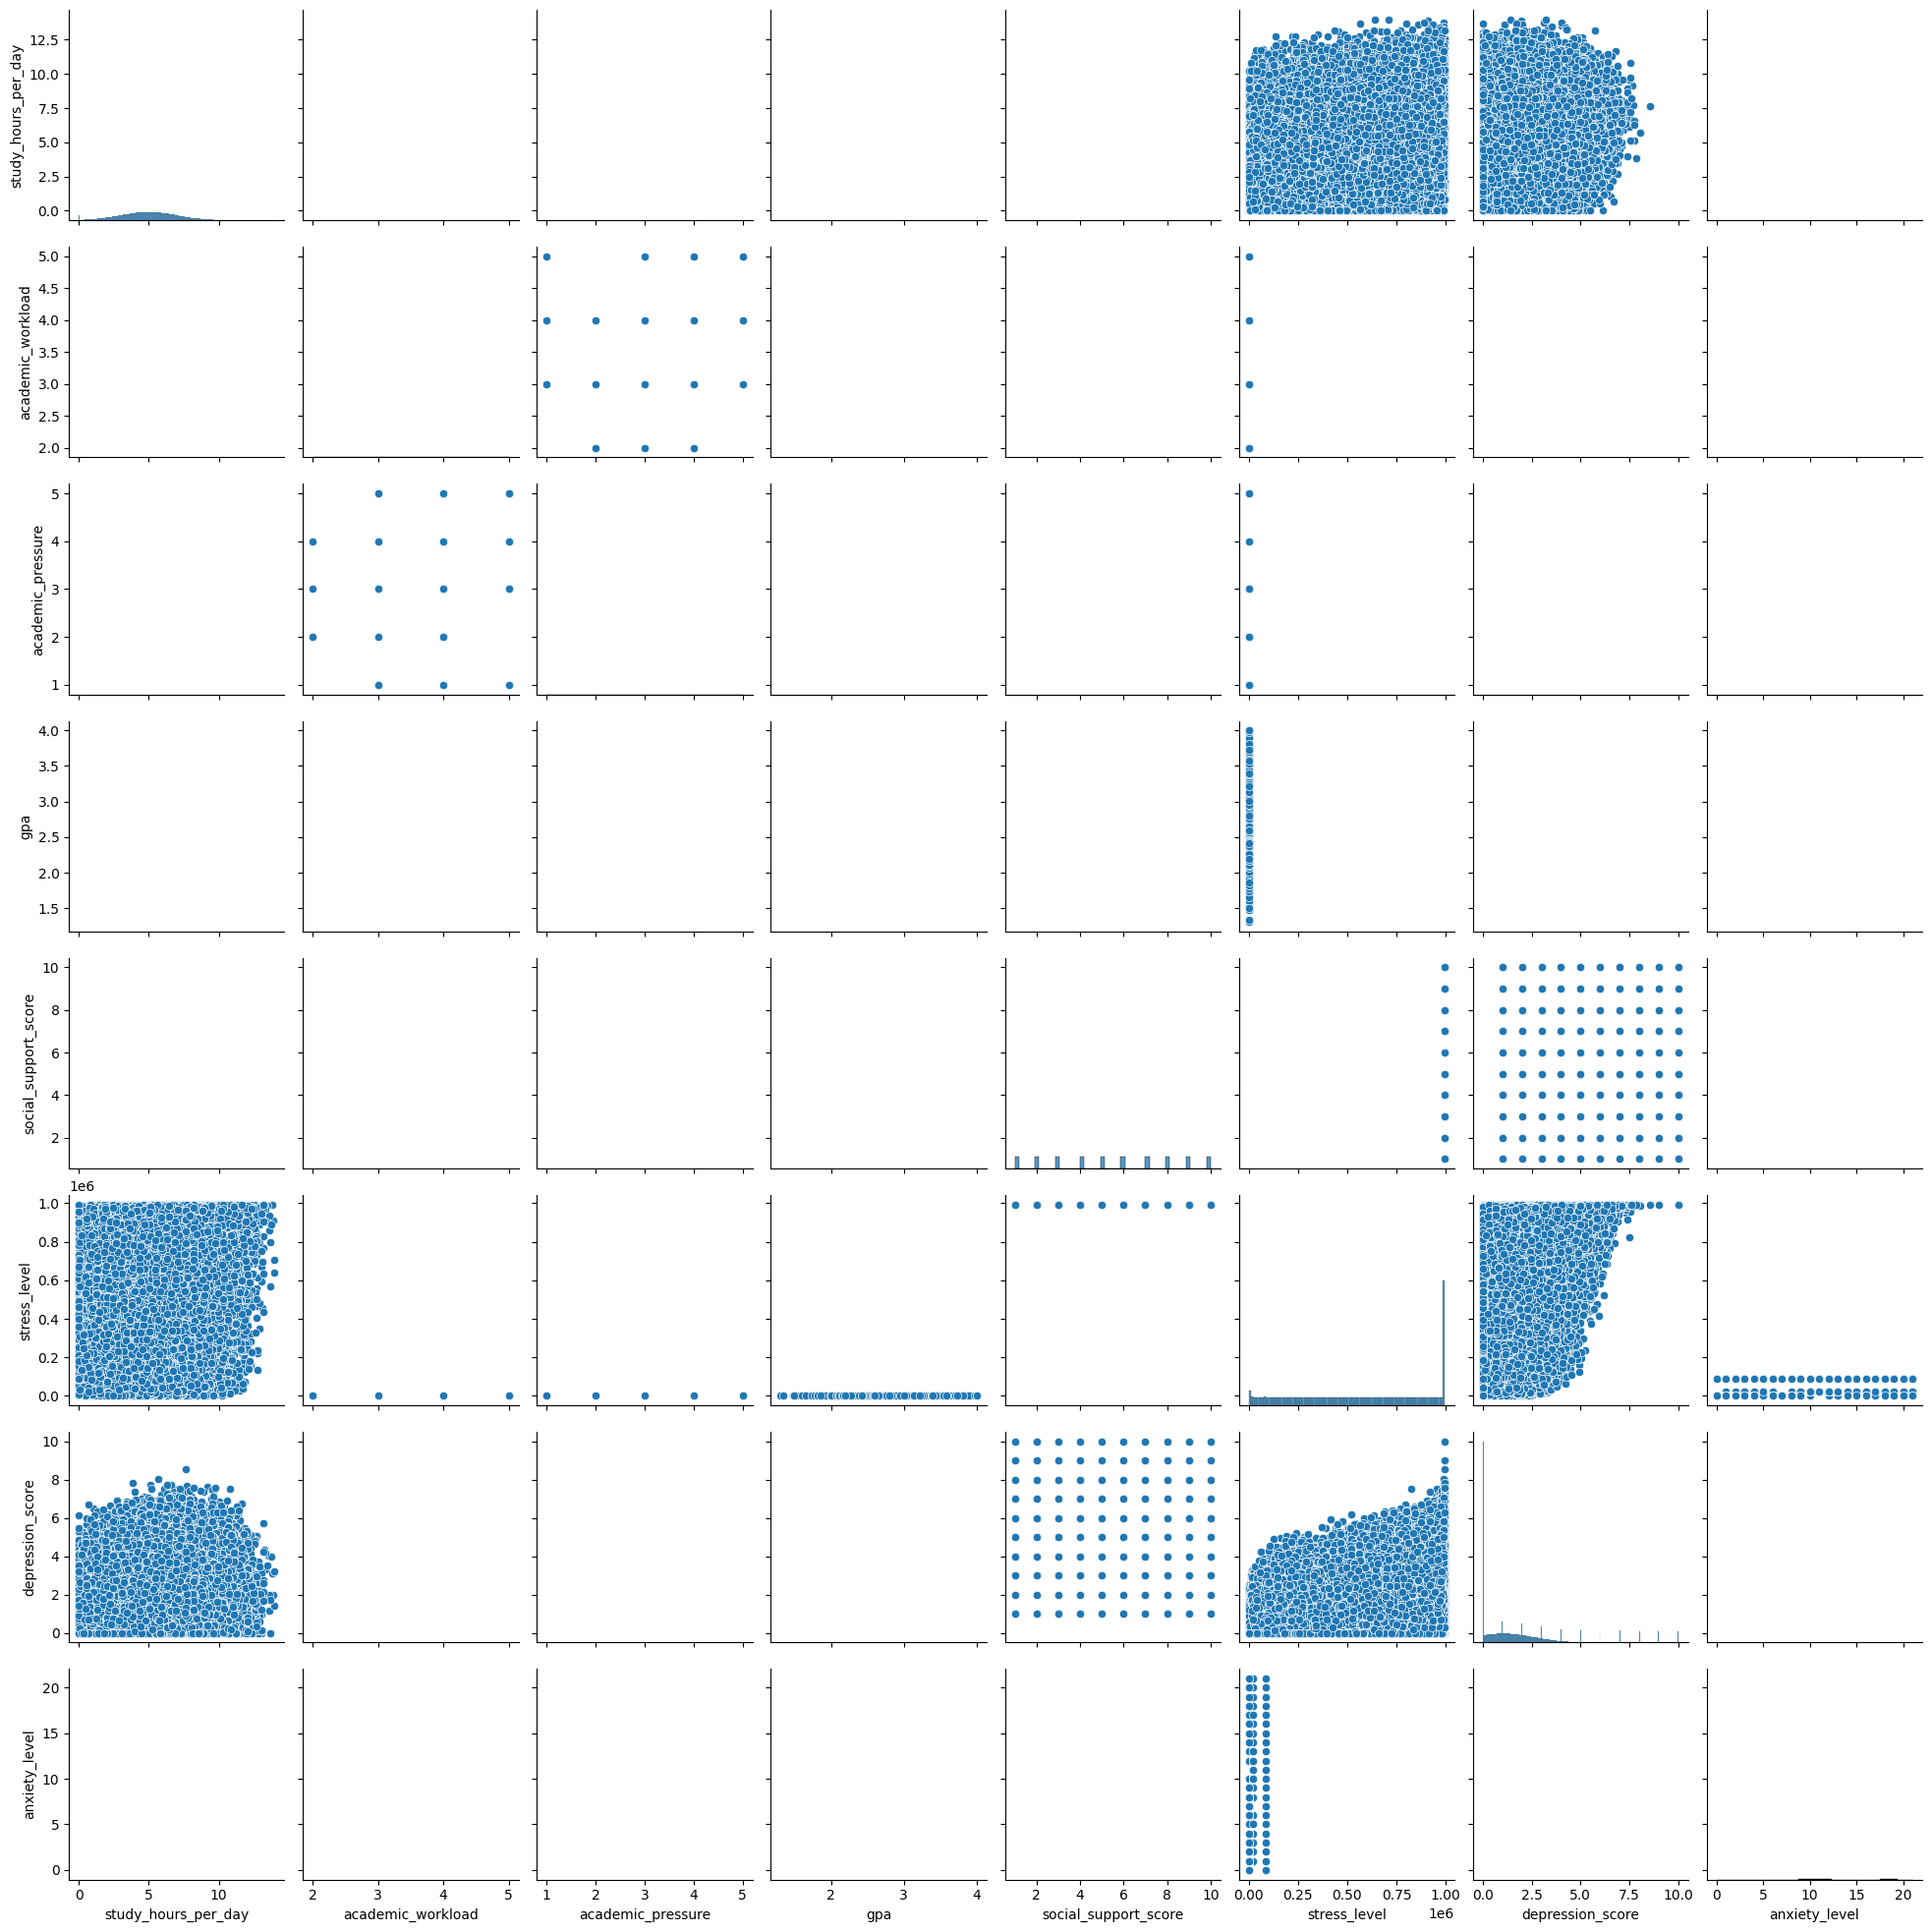

hello4


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# LOAD DATASETS
# -------------------------
files = [
    "student_mental_health_burnout.csv",
    "student_mental_health_burnout_1M.csv",
    "data.csv",
    "MentalHealthSurvey.csv",
    "StressLevelDataset.csv"
]

dfs = []

for file in files:
    try:
        temp_df = pd.read_csv(file)
        temp_df.columns = temp_df.columns.str.lower().str.strip()
        dfs.append(temp_df)
        print(f"{file} loaded")
    except Exception as e:
        print(f"Error loading {file}: {e}")

# -------------------------
# COMBINE DATASETS
# -------------------------
df = pd.concat(dfs, ignore_index=True)

print("\n=== ALL COLUMNS ===")
print(df.columns.tolist())

# -------------------------
# SELECT EXISTING COLUMNS ONLY
# -------------------------
selected_columns = [
    "study_hours_per_day",
    "academic_workload",
    "academic_pressure",
    "gpa",
    "social_support_score",
    "peer_pressure_score",
    "stress_level",
    "depression_score",
    "anxiety_level",
    "mental_health_risk"
]

existing_columns = [col for col in selected_columns if col in df.columns]
df = df[existing_columns]

print("\n=== COLUMNS USED ===")
print(existing_columns)

# -------------------------
# BASIC INFO
# -------------------------
print("\n=== INFO ===")
print(df.info())

print("\n=== STATS ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print("Total duplicates:", df.duplicated().sum())

# -------------------------
# HISTOGRAMS
# -------------------------
if len(df.columns) > 0:
    df.hist(figsize=(12, 10))
    plt.suptitle("Distributions", fontsize=16)
    plt.tight_layout()
    plt.show()
print("helo1")
# -------------------------
# BOXPLOT (Outliers)
# -------------------------
if len(df.columns) > 0:
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df)
    plt.xticks(rotation=45)
    plt.title("Outlier Detection")
    plt.show()
print("hello2")
# -------------------------
# ENCODE CATEGORICAL DATA
# -------------------------
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

# -------------------------
# CORRELATION HEATMAP
# -------------------------
if len(df_encoded.columns) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()
print("hello3")
# -------------------------
# PAIRPLOT
# -------------------------
if len(df_encoded.columns) > 1:
    sns.pairplot(df_encoded)
    plt.show()
print("hello4")